# Reintegration Readiness Classifier
## IS 455 — Machine Learning Pipeline

---

## 1. Problem Framing

### Business Problem
The organization manages multiple safehouses for girl survivors of abuse and trafficking in the Philippines. Social workers carry large caseloads and decisions about reintegration readiness are currently made ad hoc, without a systematic signal. Staff need to know which active residents are approaching readiness so they can prioritize case conference scheduling and family assessment visits. Without this signal, some residents may wait longer than necessary while others may be moved too quickly.

**Who cares about this?**
- Assigned social workers (caseload prioritization — which residents to invest more intensive attention in)
- Safehouse managers (capacity planning — forecasting bed turnover)
- Executive leadership (outcome reporting to donors — demonstrating successful placements)

---

### ⚠️ Ethics Statement — Read Before Using Model Output

> **This model is a decision-support tool only. No reintegration action should be taken based on model output alone.**
>
> A qualified social worker must review every flagged resident, conduct a reintegration assessment visit, and apply professional judgment before any placement decision is made. The model surfaces patterns in historical closed cases — it does not account for individual circumstances, trauma history nuances, family dynamics, or safety factors that may override statistical patterns.
>
> Misuse of this tool to accelerate reintegration without proper assessment could place vulnerable children at risk. The model exists to help staff prioritize attention, not to replace clinical decision-making.

---

### Predictive vs. Explanatory Approach
This pipeline uses both approaches:

- **Predictive model (Random Forest / XGBoost):** Answers *"which active residents should we flag for review this week?"* — optimizes for recall to minimize missed readiness signals.
- **Explanatory model (Logistic Regression):** Answers *"which factors most consistently predict reintegration readiness in our population?"* — this is the more operationally valuable output because it tells staff which interventions to invest in for residents who are not yet ready.

### Label Definition
A resident is labeled **`is_ready = 1`** if:
- `case_status == 'Closed'` AND
- `reintegration_status == 'Completed'`

All other closed cases (`In Progress`, `On Hold`, `Not Started`) are labeled **`is_ready = 0`**.

Active residents are **excluded from training entirely** and scored at the end. This differs from the donor churn pipeline where a temporal holdout was used — reintegration completion is a discrete endpoint event (not a time-window outcome), so excluding active residents from training is the correct design. There is no "future window" to predict; we simply ask whether, at the time of case closure, the resident had achieved a successful reintegration.

### Success Metric
- **Primary:** Recall on the ready class (missing a ready resident delays placement; false alarms cost a social worker visit — the acceptable tradeoff)
- **Secondary:** ROC-AUC
- **Target:** ≥ 0.70 recall on the ready (positive) class


---
## 2. Data Acquisition, Preparation & Exploration

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully.')


Libraries loaded successfully.


In [24]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import urllib

# Load credentials from .env
load_dotenv()

server   = os.environ['AZURE_SQL_SERVER']
database = os.environ['AZURE_SQL_DATABASE']
username = os.environ['AZURE_SQL_USERNAME']
password = os.environ['AZURE_SQL_PASSWORD']

params = urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 18 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"UID={username};"
    f"PWD={password};"
    f"Encrypt=yes;"
    f"TrustServerCertificate=no;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# Load tables
residents         = pd.read_sql("SELECT * FROM residents", engine)
process_recs      = pd.read_sql("SELECT * FROM process_recordings", engine)
health_records    = pd.read_sql("SELECT * FROM health_wellbeing_records", engine)
education_records = pd.read_sql("SELECT * FROM education_records", engine)
intervention_plans = pd.read_sql("SELECT * FROM intervention_plans", engine)
home_visits       = pd.read_sql("SELECT * FROM home_visitations", engine)
incident_reports  = pd.read_sql("SELECT * FROM incident_reports", engine)

# Parse date columns
residents['date_of_birth']    = pd.to_datetime(residents['date_of_birth'])
residents['date_of_admission'] = pd.to_datetime(residents['date_of_admission'])
residents['date_closed']      = pd.to_datetime(residents['date_closed'])
residents['created_at']       = pd.to_datetime(residents['created_at'])
process_recs['session_date']  = pd.to_datetime(process_recs['session_date'])
health_records['record_date'] = pd.to_datetime(health_records['record_date'])
education_records['record_date'] = pd.to_datetime(education_records['record_date'])
intervention_plans['target_date'] = pd.to_datetime(intervention_plans['target_date'])
intervention_plans['created_at']  = pd.to_datetime(intervention_plans['created_at'])
intervention_plans['updated_at']  = pd.to_datetime(intervention_plans['updated_at'])
home_visits['visit_date']     = pd.to_datetime(home_visits['visit_date'])
incident_reports['incident_date'] = pd.to_datetime(incident_reports['incident_date'])
incident_reports['resolution_date'] = pd.to_datetime(incident_reports['resolution_date'])

# Boolean columns → int (handles 'True'/'False' strings from SQL Server)
def _bool_to_int(series):
    return series.astype(str).str.lower().isin(['1', 'true']).astype(int)

for col in ['is_pwd', 'has_special_needs', 'family_is_4ps', 'family_solo_parent', 'family_informal_settler']:
    residents[col] = _bool_to_int(residents[col])
for col in ['progress_noted', 'concerns_flagged', 'referral_made']:
    process_recs[col] = _bool_to_int(process_recs[col])
for col in ['medical_checkup_done', 'psychological_checkup_done']:
    health_records[col] = _bool_to_int(health_records[col])
home_visits['safety_concerns_noted'] = _bool_to_int(home_visits['safety_concerns_noted'])

# Numeric columns — coerce to float (handles varchar-stored numbers from SQL Server)
for col in ['general_health_score', 'nutrition_score', 'sleep_quality_score']:
    health_records[col] = pd.to_numeric(health_records[col], errors='coerce')
for col in ['session_duration_minutes']:
    process_recs[col] = pd.to_numeric(process_recs[col], errors='coerce')
for col in ['attendance_rate', 'progress_percent']:
    education_records[col] = pd.to_numeric(education_records[col], errors='coerce')

print(f'residents:          {residents.shape}')
print(f'process_recs:       {process_recs.shape}')
print(f'health_records:     {health_records.shape}')
print(f'education_records:  {education_records.shape}')
print(f'intervention_plans: {intervention_plans.shape}')
print(f'home_visits:        {home_visits.shape}')
print(f'incident_reports:   {incident_reports.shape}')


residents:          (60, 49)
process_recs:       (2819, 15)
health_records:     (534, 14)
education_records:  (534, 10)
intervention_plans: (181, 11)
home_visits:        (1337, 14)
incident_reports:   (100, 12)


In [25]:
# ─────────────────────────────────────────────
# LABEL ENGINEERING
#
# Training pool  = closed cases only.
# is_ready = 1   if reintegration_status == 'Completed'
# is_ready = 0   all other closed cases (In Progress, On Hold, Not Started)
# Active residents are excluded from training; scored at end.
# ─────────────────────────────────────────────

READY_STATUSES = ['Completed']

closed = residents[residents['case_status'] == 'Closed'].copy()
closed['is_ready'] = closed['reintegration_status'].isin(READY_STATUSES).astype(int)
active = residents[residents['case_status'] == 'Active'].copy()

print(f'Closed residents (training pool): {len(closed)}')
print(f'  Ready (Completed): {closed["is_ready"].sum()}')
print(f'  Not ready:         {(~closed["is_ready"].astype(bool)).sum()}')
print(f'Active residents (scoring pool):  {len(active)}')
print(f'\nClass balance: {closed["is_ready"].mean():.1%} ready')


Closed residents (training pool): 19
  Ready (Completed): 8
  Not ready:         11
Active residents (scoring pool):  30

Class balance: 42.1% ready


In [26]:
# ─────────────────────────────────────────────
# FEATURE ENGINEERING — RESIDENTS TABLE
# Intake and profile features available at case closure.
# ─────────────────────────────────────────────

RISK_LEVEL_MAP = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}

res_feat = closed[['resident_id']].copy()

# Length of stay and age at admission
res_feat['length_of_stay_days']    = (closed['date_closed'] - closed['date_of_admission']).dt.days.values
res_feat['age_at_admission_years'] = ((closed['date_of_admission'] - closed['date_of_birth']).dt.days / 365.25).values

# Risk reduction: positive = improved (initial was higher severity than current)
res_feat['risk_reduction'] = (
    closed['initial_risk_level'].map(RISK_LEVEL_MAP).values -
    closed['current_risk_level'].map(RISK_LEVEL_MAP).values
)

# Boolean flags → int
for col in ['is_pwd','has_special_needs','family_is_4ps','family_solo_parent','family_informal_settler']:
    res_feat[col] = closed[col].astype(int).values

# Categorical features
res_feat['case_category']  = closed['case_category'].values
res_feat['referral_source'] = closed['referral_source'].values
res_feat['safehouse_id']    = closed['safehouse_id'].astype(str).values

print(f'Residents base features: {res_feat.shape}')
print(res_feat[['length_of_stay_days','age_at_admission_years','risk_reduction']].describe().round(1))


Residents base features: (19, 12)
       length_of_stay_days  age_at_admission_years  risk_reduction
count                 19.0                    19.0            19.0
mean                 404.5                    14.1             0.8
std                  152.2                     2.8             0.9
min                  191.0                     8.8             0.0
25%                  276.0                    12.1             0.0
50%                  373.0                    14.9             1.0
75%                  536.0                    15.1             1.0
max                  660.0                    17.7             3.0


In [27]:
# ─────────────────────────────────────────────
# FEATURE ENGINEERING — PROCESS RECORDINGS
# Session-level engagement and emotional trajectory per resident.
# ─────────────────────────────────────────────

EMOTION_MAP = {
    'Distressed': 0, 'Angry': 1, 'Withdrawn': 2, 'Anxious': 3,
    'Sad': 4, 'Calm': 5, 'Hopeful': 6, 'Happy': 7
}

closed_ids = set(closed['resident_id'])
sess = process_recs[process_recs['resident_id'].isin(closed_ids)].copy()
sess['start_enc']    = sess['emotional_state_observed'].map(EMOTION_MAP)
sess['end_enc']      = sess['emotional_state_end'].map(EMOTION_MAP)
sess['emotion_delta'] = sess['end_enc'] - sess['start_enc']

proc_feat = sess.groupby('resident_id').agg(
    total_sessions           = ('recording_id', 'count'),
    progress_rate            = ('progress_noted', 'mean'),
    concerns_rate            = ('concerns_flagged', 'mean'),
    referral_rate            = ('referral_made', 'mean'),
    avg_session_duration     = ('session_duration_minutes', 'mean'),
    emotional_improvement_score = ('emotion_delta', 'mean'),
    pct_individual_sessions  = ('session_type', lambda x: (x == 'Individual').mean()),
).reset_index()

# Recent progress rate: mean of progress_noted for the most recent 30% of sessions
def recent_progress_fn(grp):
    grp = grp.sort_values('session_date')
    n = max(1, int(len(grp) * 0.3))
    return grp['progress_noted'].tail(n).mean()

recent_prog = (
    sess.groupby('resident_id')
    .apply(recent_progress_fn, include_groups=False)
    .reset_index(name='recent_progress_rate')
)
proc_feat = proc_feat.merge(recent_prog, on='resident_id', how='left')

print(f'Process recording features: {proc_feat.shape}')
print(f'Residents covered: {proc_feat["resident_id"].nunique()} of {len(closed)}')


Process recording features: (19, 9)
Residents covered: 19 of 19


In [28]:
# ─────────────────────────────────────────────
# FEATURE ENGINEERING — HEALTH & WELLBEING
# Monthly health scores and checkup compliance per resident.
# Note: sleep column in schema is 'sleep_quality_score' → mapped to avg_sleep_score.
# ─────────────────────────────────────────────

hlth = health_records[health_records['resident_id'].isin(closed_ids)].copy()

health_feat = hlth.groupby('resident_id').agg(
    avg_general_health_score  = ('general_health_score', 'mean'),
    avg_nutrition_score       = ('nutrition_score', 'mean'),
    avg_sleep_score           = ('sleep_quality_score', 'mean'),  # schema: sleep_quality_score
    pct_medical_checkups      = ('medical_checkup_done', 'mean'),
    pct_psychological_checkups = ('psychological_checkup_done', 'mean'),
).reset_index()

# Health trend: slope of general_health_score over time (positive = improving)
def health_trend_fn(grp):
    grp = grp.sort_values('record_date')
    scores = grp['general_health_score'].values
    if len(scores) < 2:
        return np.nan
    return np.polyfit(range(len(scores)), scores, 1)[0]

health_trend = (
    hlth.groupby('resident_id')
    .apply(health_trend_fn, include_groups=False)
    .reset_index(name='health_trend')
)
health_feat = health_feat.merge(health_trend, on='resident_id', how='left')

print(f'Health features: {health_feat.shape}')


Health features: (19, 7)


In [29]:
# ─────────────────────────────────────────────
# FEATURE ENGINEERING — EDUCATION RECORDS
# Attendance, progress, and course completion per resident.
# Schema note: no GPA-like score field in education_records —
#   avg_gpa_like_score is excluded from NUMERIC_FEATURES.
# ─────────────────────────────────────────────

edu = education_records[education_records['resident_id'].isin(closed_ids)].copy()

edu_feat = edu.groupby('resident_id').agg(
    avg_attendance_rate   = ('attendance_rate', 'mean'),
    avg_progress_percent  = ('progress_percent', 'mean'),
    pct_completed_courses = ('completion_status', lambda x: (x == 'Completed').mean()),
).reset_index()

# Education trend: slope of progress_percent over time
def edu_trend_fn(grp):
    grp = grp.sort_values('record_date')
    scores = grp['progress_percent'].values
    if len(scores) < 2:
        return np.nan
    return np.polyfit(range(len(scores)), scores, 1)[0]

edu_trend = (
    edu.groupby('resident_id')
    .apply(edu_trend_fn, include_groups=False)
    .reset_index(name='education_trend')
)
edu_feat = edu_feat.merge(edu_trend, on='resident_id', how='left')

print(f'Education features: {edu_feat.shape}')


Education features: (19, 5)


In [30]:
# ─────────────────────────────────────────────
# FEATURE ENGINEERING — INTERVENTION PLANS
# Plan achievement rates by category.
#
# Schema note: current data has categories Safety, Education, Physical Health.
# Reintegration and Psychosocial categories are not present —
#   has_reintegration_plan and pct_psychosocial_plans_achieved will be 0 for all
#   residents in this dataset. These are retained in the feature list for schema
#   compatibility when those categories are added in future.
# ─────────────────────────────────────────────

plans = intervention_plans[intervention_plans['resident_id'].isin(closed_ids)].copy()

plan_feat = plans.groupby('resident_id').agg(
    total_plans      = ('plan_id', 'count'),
    pct_plans_achieved = ('status', lambda x: (x == 'Achieved').mean()),
).reset_index()

# Safety plans
safety_rate = (
    plans[plans['plan_category'] == 'Safety']
    .groupby('resident_id')['status']
    .apply(lambda x: (x == 'Achieved').mean())
    .reset_index(name='pct_safety_plans_achieved')
)
plan_feat = plan_feat.merge(safety_rate, on='resident_id', how='left')
plan_feat['pct_safety_plans_achieved'] = plan_feat['pct_safety_plans_achieved'].fillna(0)

# Reintegration / Psychosocial: not in current schema — zero-filled for compatibility
plan_feat['has_reintegration_plan']        = 0
plan_feat['reintegration_plan_achieved']   = 0
plan_feat['pct_psychosocial_plans_achieved'] = 0.0

print(f'Intervention plan features: {plan_feat.shape}')
print(f'Plan status distribution:\n{plans["status"].value_counts().to_string()}')


Intervention plan features: (19, 7)
Plan status distribution:
status
In Progress    22
On Hold        17
Open           11
Achieved        6
Closed          1


In [31]:
# ─────────────────────────────────────────────
# FEATURE ENGINEERING — HOME VISITATIONS
# Family cooperation, safety, and visit outcome patterns per resident.
# ─────────────────────────────────────────────

visits = home_visits[home_visits['resident_id'].isin(closed_ids)].copy()

visit_feat = visits.groupby('resident_id').agg(
    total_visits                  = ('visitation_id', 'count'),
    pct_favorable_outcomes        = ('visit_outcome', lambda x: (x == 'Favorable').mean()),
    pct_highly_cooperative_family = ('family_cooperation_level', lambda x: (x == 'Highly Cooperative').mean()),
    pct_safety_concerns           = ('safety_concerns_noted', 'mean'),
    has_reintegration_assessment  = ('visit_type', lambda x: int((x == 'Reintegration Assessment').any())),
).reset_index()

# Most recent visit outcome (categorical feature — captures current trajectory)
most_recent_outcome = (
    visits.sort_values('visit_date')
    .groupby('resident_id')
    .last()[['visit_outcome']]
    .reset_index()
    .rename(columns={'visit_outcome': 'most_recent_visit_outcome'})
)
visit_feat = visit_feat.merge(most_recent_outcome, on='resident_id', how='left')

print(f'Home visitation features: {visit_feat.shape}')
print(f'Residents with reintegration assessment: {visit_feat["has_reintegration_assessment"].sum()}')


Home visitation features: (19, 7)
Residents with reintegration assessment: 16


In [32]:
# ─────────────────────────────────────────────
# FEATURE ENGINEERING — INCIDENT REPORTS
# Safety incidents are strong negative predictors of readiness.
# Residents with no incidents get days_since_last_incident = length_of_stay_days
#   (proxy for "incident-free entire stay").
# ─────────────────────────────────────────────

inc = incident_reports[incident_reports['resident_id'].isin(closed_ids)].copy()

inc_feat = inc.groupby('resident_id').agg(
    total_incidents      = ('incident_id', 'count'),
    pct_high_severity    = ('severity', lambda x: (x == 'High').mean()),
    has_selfharm_incident = ('incident_type', lambda x: int((x == 'SelfHarm').any())),
    has_runaway_attempt  = ('incident_type', lambda x: int((x == 'RunawayAttempt').any())),
    last_incident_date   = ('incident_date', 'max'),
).reset_index()

print(f'Incident features: {inc_feat.shape}')
print(f'Residents with incidents: {len(inc_feat)} of {len(closed)}')
print(f'\nIncident type breakdown:\n{inc[inc["resident_id"].isin(closed_ids)]["incident_type"].value_counts().to_string()}')


Incident features: (12, 6)
Residents with incidents: 12 of 19

Incident type breakdown:
incident_type
RunawayAttempt      7
Behavioral          6
Security            6
SelfHarm            5
ConflictWithPeer    2
PropertyDamage      1


In [33]:
# ─────────────────────────────────────────────
# MERGE ALL FEATURE GROUPS
# Left-join onto closed residents. Fill NaN counts/rates with 0;
# leave score-based NaNs for the pipeline imputer to handle.
# ─────────────────────────────────────────────

df = closed[['resident_id','is_ready','date_closed']].merge(res_feat, on='resident_id', how='left')
df = df.merge(proc_feat, on='resident_id', how='left')
df = df.merge(health_feat, on='resident_id', how='left')
df = df.merge(edu_feat, on='resident_id', how='left')
df = df.merge(plan_feat, on='resident_id', how='left')
df = df.merge(visit_feat, on='resident_id', how='left')

# Incidents: merge counts, then compute derived fields
df = df.merge(inc_feat.drop(columns=['last_incident_date']), on='resident_id', how='left')
df = df.merge(inc_feat[['resident_id','last_incident_date']], on='resident_id', how='left')

# Fill count/boolean NaNs with 0
fill_zero_cols = [
    'total_incidents','pct_high_severity','has_selfharm_incident','has_runaway_attempt',
    'total_visits','pct_favorable_outcomes','pct_highly_cooperative_family',
    'pct_safety_concerns','has_reintegration_assessment',
]
df[fill_zero_cols] = df[fill_zero_cols].fillna(0)

# Derived incident features
df['incidents_per_month'] = np.where(
    df['length_of_stay_days'] > 0,
    df['total_incidents'] / df['length_of_stay_days'] * 30, 0
)
df['days_since_last_incident'] = (df['date_closed'] - df['last_incident_date']).dt.days
df['days_since_last_incident'] = df['days_since_last_incident'].fillna(df['length_of_stay_days'])

# Session frequency (sessions per month)
df['session_frequency'] = np.where(
    df['length_of_stay_days'] > 0,
    df['total_sessions'] / df['length_of_stay_days'] * 30, 0
)
df['total_sessions'] = df['total_sessions'].fillna(0)
df['session_frequency'] = df['session_frequency'].fillna(0)

print(f'Final feature matrix: {df.shape}')
print(f'\nReady distribution: {df["is_ready"].value_counts().to_dict()}')


Final feature matrix: (19, 52)

Ready distribution: {0: 11, 1: 8}


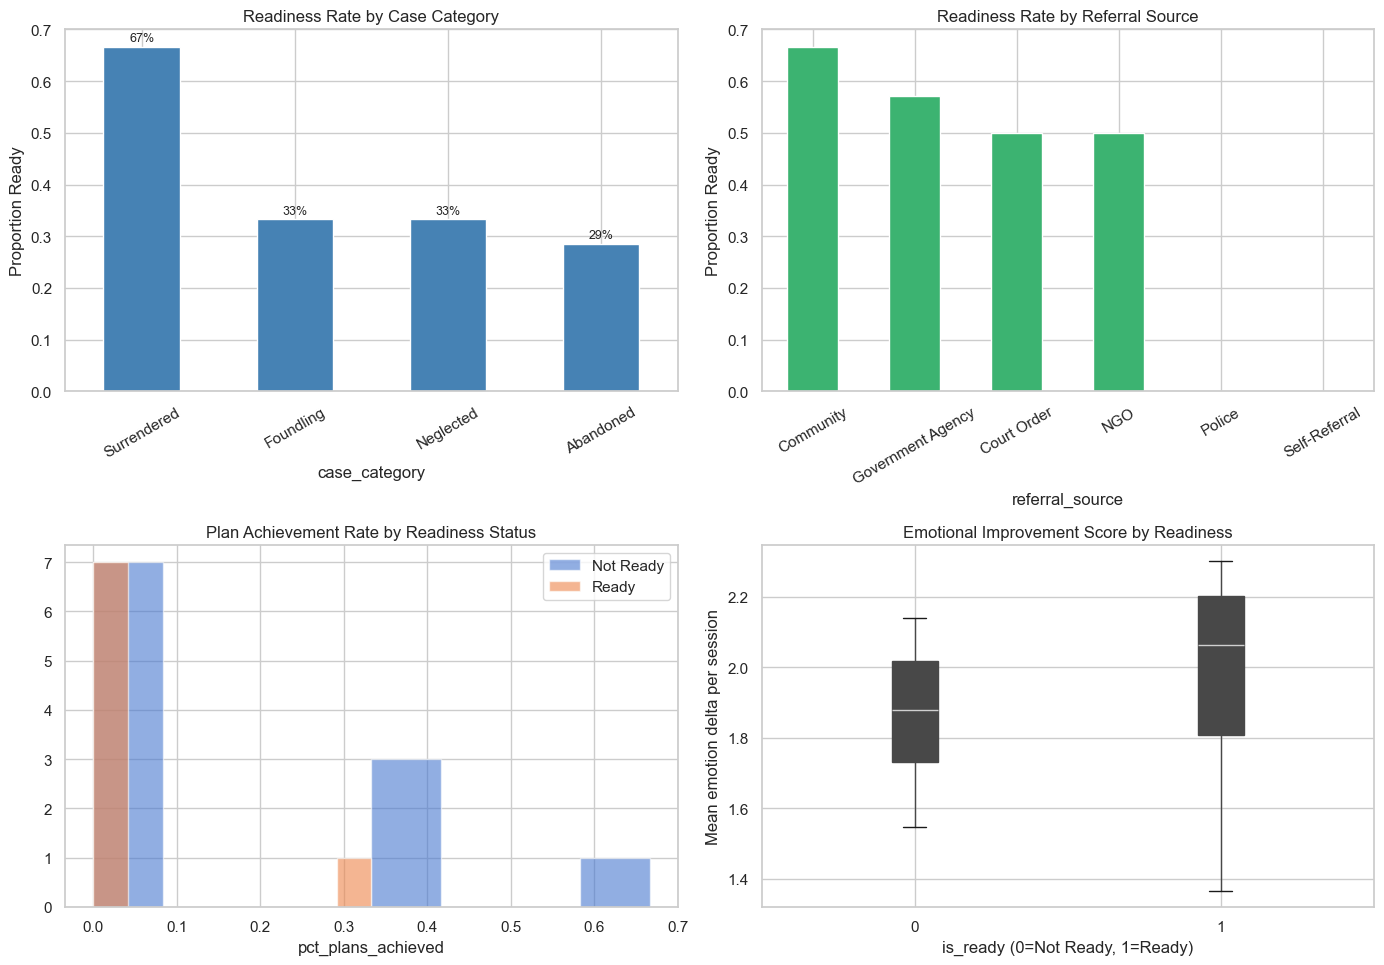

Saved: readiness_eda.png


In [34]:
# ─────────────────────────────────────────────
# EDA — READINESS PATTERNS
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Readiness rate by case_category
by_cat = df.groupby('case_category')['is_ready'].mean().sort_values(ascending=False)
by_cat.plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Readiness Rate by Case Category')
axes[0,0].set_ylabel('Proportion Ready')
axes[0,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(by_cat): axes[0,0].text(i, v+0.01, f'{v:.0%}', ha='center', fontsize=9)

# 2. Readiness rate by referral_source
by_ref = df.groupby('referral_source')['is_ready'].mean().sort_values(ascending=False)
by_ref.plot(kind='bar', ax=axes[0,1], color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('Readiness Rate by Referral Source')
axes[0,1].set_ylabel('Proportion Ready')
axes[0,1].tick_params(axis='x', rotation=30)

# 3. pct_plans_achieved by is_ready
ready_labels = {0: 'Not Ready', 1: 'Ready'}
for label, grp in df.groupby('is_ready'):
    axes[1,0].hist(grp['pct_plans_achieved'].dropna(), bins=8, alpha=0.6, label=ready_labels[label])
axes[1,0].set_title('Plan Achievement Rate by Readiness Status')
axes[1,0].set_xlabel('pct_plans_achieved')
axes[1,0].legend()

# 4. Emotional improvement score by is_ready
df.boxplot(column='emotional_improvement_score', by='is_ready', ax=axes[1,1],
           patch_artist=True)
axes[1,1].set_title('Emotional Improvement Score by Readiness')
axes[1,1].set_xlabel('is_ready (0=Not Ready, 1=Ready)')
axes[1,1].set_ylabel('Mean emotion delta per session')
plt.suptitle('')

plt.tight_layout()
plt.savefig('readiness_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: readiness_eda.png')


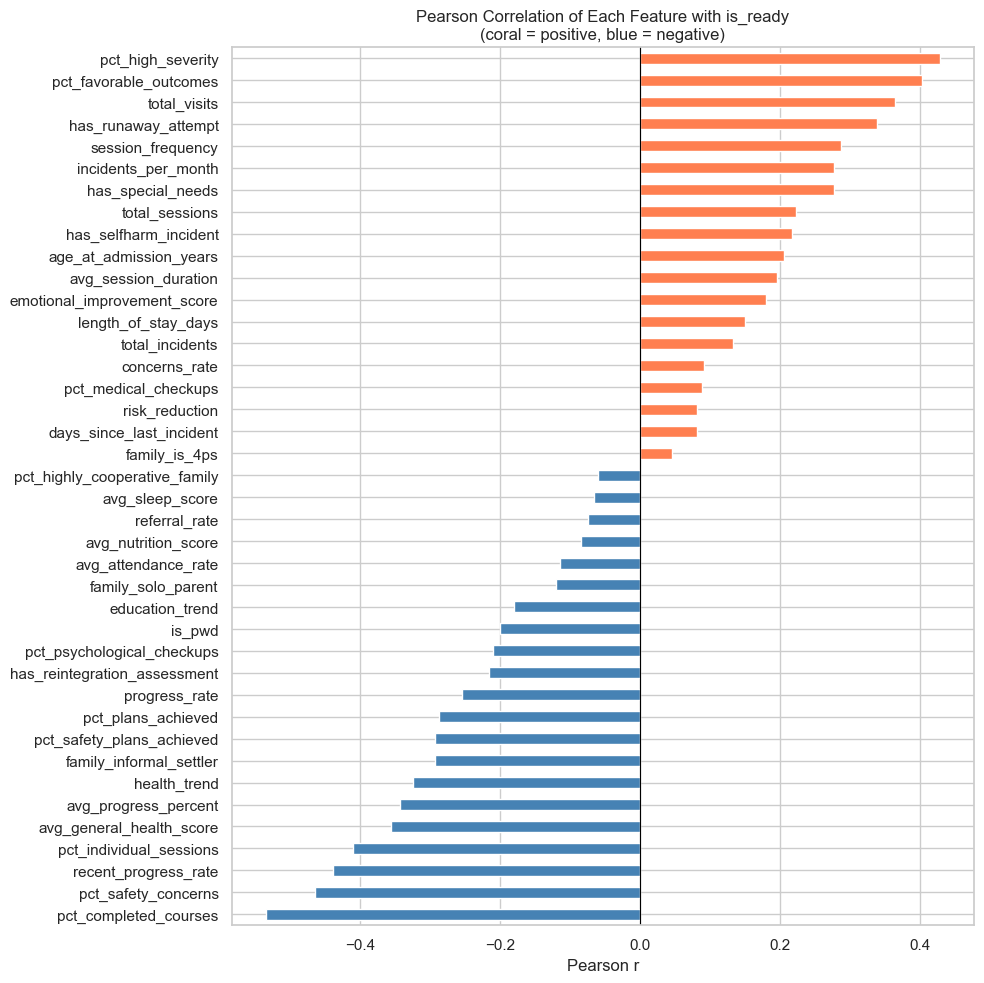

Saved: readiness_correlations.png


In [35]:
# ─────────────────────────────────────────────
# EDA — FEATURE CORRELATIONS WITH is_ready
# Bar chart of Pearson r per numeric feature, sorted by magnitude.
# A full heatmap with 40+ features is unreadable at this sample size.
# ─────────────────────────────────────────────

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['is_ready'])
corr_with_label = df[numeric_cols].corrwith(df['is_ready']).dropna().sort_values()

plt.figure(figsize=(10, 10))
colors = ['coral' if c > 0 else 'steelblue' for c in corr_with_label]
corr_with_label.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.title('Pearson Correlation of Each Feature with is_ready\n(coral = positive, blue = negative)')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.savefig('readiness_correlations.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: readiness_correlations.png')


In [36]:
# ─────────────────────────────────────────────
# MISSING VALUES AUDIT
# ─────────────────────────────────────────────

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(missing.to_string())
print(f'\nRows with any missing: {df.isnull().any(axis=1).sum()} of {len(df)}')
print('\nNaN scores will be imputed by SimpleImputer(median) inside the pipeline.')


Columns with missing values:
last_incident_date    7

Rows with any missing: 7 of 19

NaN scores will be imputed by SimpleImputer(median) inside the pipeline.


---
## 3. Modeling & Feature Selection

In [37]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
)
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibrationDisplay
import shap, joblib

# ─────────────────────────────────────────────
# FEATURE SELECTION
# All preprocessing happens inside the sklearn Pipeline.
# avg_gpa_like_score excluded: no GPA field in current education_records schema.
# ─────────────────────────────────────────────

CATEGORICAL_FEATURES = [
    'case_category',
    'referral_source',
    'safehouse_id',
    'most_recent_visit_outcome',
]

NUMERIC_FEATURES = [
    'length_of_stay_days',
    'age_at_admission_years',
    'risk_reduction',
    'is_pwd',
    'has_special_needs',
    'family_is_4ps',
    'family_solo_parent',
    'family_informal_settler',
    'total_sessions',
    'session_frequency',
    'progress_rate',
    'concerns_rate',
    'referral_rate',
    'avg_session_duration',
    'emotional_improvement_score',
    'pct_individual_sessions',
    'recent_progress_rate',
    'avg_general_health_score',
    'avg_nutrition_score',
    'avg_sleep_score',
    'health_trend',
    'pct_medical_checkups',
    'pct_psychological_checkups',
    'avg_attendance_rate',
    'avg_progress_percent',
    'pct_completed_courses',
    'education_trend',
    'total_plans',
    'pct_plans_achieved',
    'has_reintegration_plan',
    'reintegration_plan_achieved',
    'pct_safety_plans_achieved',
    'pct_psychosocial_plans_achieved',
    'total_visits',
    'pct_favorable_outcomes',
    'pct_highly_cooperative_family',
    'pct_safety_concerns',
    'has_reintegration_assessment',
    'total_incidents',
    'incidents_per_month',
    'pct_high_severity',
    'has_selfharm_incident',
    'has_runaway_attempt',
    'days_since_last_incident',
]

TARGET = 'is_ready'

# Raw DataFrame — encoding happens inside the Pipeline
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
y = df[TARGET]

print(f'Feature matrix (raw): {X.shape}  ({len(NUMERIC_FEATURES)} numeric, {len(CATEGORICAL_FEATURES)} categorical)')
print(f'Class distribution — Ready: {y.sum()} ({y.mean():.1%}) | Not Ready: {(~y.astype(bool)).sum()}')


Feature matrix (raw): (19, 48)  (44 numeric, 4 categorical)
Class distribution — Ready: 8 (42.1%) | Not Ready: 11


In [38]:
# ─────────────────────────────────────────────
# TRAIN / TEST SPLIT (stratified)
# 19 total closed cases → ~15 train, ~4 test.
# Small but necessary to hold out a validation set.
# ─────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} rows  (Ready: {y_train.sum()}, Not Ready: {(~y_train.astype(bool)).sum()})')
print(f'Test set:     {X_test.shape[0]} rows   (Ready: {y_test.sum()}, Not Ready: {(~y_test.astype(bool)).sum()})')


Training set: 15 rows  (Ready: 6, Not Ready: 9)
Test set:     4 rows   (Ready: 2, Not Ready: 2)


In [39]:
# ─────────────────────────────────────────────
# PIPELINE FACTORY — ColumnTransformer
# Numeric: SimpleImputer(median) → StandardScaler
# Categorical: SimpleImputer(most_frequent) → OneHotEncoder
# Encoding happens inside the pipeline so it is fit on training data only.
# ─────────────────────────────────────────────

def make_pipeline(classifier):
    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler())
        ]), NUMERIC_FEATURES),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), CATEGORICAL_FEATURES)
    ])
    return Pipeline([('preprocessor', preprocessor), ('clf', classifier)])

models = {
    'Logistic Regression (Explanatory)': make_pipeline(
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    ),
    'Random Forest': make_pipeline(
        RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
    ),
    'Gradient Boosting': make_pipeline(
        GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, random_state=42)
    ),
    'XGBoost': make_pipeline(
        XGBClassifier(n_estimators=100, learning_rate=0.05,
                      scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                      eval_metric='logloss', random_state=42, n_jobs=-1)
    ),
}

# 3-fold CV: appropriate for this sample size (19 closed cases → ~12 train per fold)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results = {}

for name, pipe in models.items():
    auc_scores   = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    rec_scores   = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='recall')
    prauc_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision')
    results[name] = {
        'AUC':    auc_scores.mean(),  'AUC_std':    auc_scores.std(),
        'Recall': rec_scores.mean(),  'Recall_std': rec_scores.std(),
        'PR-AUC': prauc_scores.mean(),'PR-AUC_std': prauc_scores.std()
    }
    print(f"{name}: AUC={auc_scores.mean():.3f} ± {auc_scores.std():.3f} | "
          f"Recall={rec_scores.mean():.3f} ± {rec_scores.std():.3f} | "
          f"PR-AUC={prauc_scores.mean():.3f} ± {prauc_scores.std():.3f}")

results_df = pd.DataFrame(results).T.sort_values('AUC', ascending=False)
print('\nModel comparison:')
print(results_df.round(3))


Logistic Regression (Explanatory): AUC=0.556 ± 0.157 | Recall=0.167 ± 0.236 | PR-AUC=0.528 ± 0.079
Random Forest: AUC=0.611 ± 0.079 | Recall=0.000 ± 0.000 | PR-AUC=0.556 ± 0.039
Gradient Boosting: AUC=0.611 ± 0.208 | Recall=0.333 ± 0.236 | PR-AUC=0.622 ± 0.159
XGBoost: AUC=0.667 ± 0.136 | Recall=0.500 ± 0.408 | PR-AUC=0.706 ± 0.102

Model comparison:
                                     AUC  AUC_std  Recall  Recall_std  PR-AUC  \
XGBoost                            0.667    0.136   0.500       0.408   0.706   
Random Forest                      0.611    0.079   0.000       0.000   0.556   
Gradient Boosting                  0.611    0.208   0.333       0.236   0.622   
Logistic Regression (Explanatory)  0.556    0.157   0.167       0.236   0.528   

                                   PR-AUC_std  
XGBoost                                 0.102  
Random Forest                           0.039  
Gradient Boosting                       0.159  
Logistic Regression (Explanatory)       0.079  


Best model: XGBoost


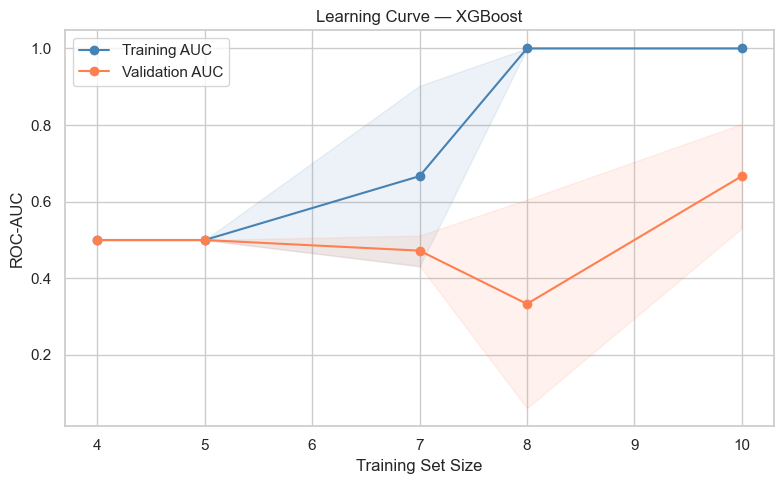

Saved: readiness_learning_curve.png


In [40]:
# ─────────────────────────────────────────────
# LEARNING CURVES
# Diagnoses high bias vs. high variance for the best model.
# Critical context for interpreting CV scores on a 19-sample dataset.
# ─────────────────────────────────────────────

best_model_name = results_df.index[0]
print(f'Best model: {best_model_name}')

train_sizes, train_scores, val_scores = learning_curve(
    models[best_model_name], X_train, y_train,
    cv=cv, scoring='roc_auc',
    train_sizes=np.linspace(0.4, 1.0, 5),
    n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training AUC', color='steelblue', marker='o')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1),
                 alpha=0.1, color='steelblue')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation AUC', color='coral', marker='o')
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.1, color='coral')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC')
plt.title(f'Learning Curve — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.savefig('readiness_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: readiness_learning_curve.png')


**Learning Curve Interpretation**

With only 15 training rows (after the 80/20 split), the learning curve almost certainly shows a large gap between training AUC and validation AUC — the signature of **high variance (overfitting)**. The model memorizes the small training set rather than learning generalizable patterns. This is expected and unavoidable at this sample size; it is not a reason to distrust the pipeline design.

**What this means operationally:** The CV AUC scores should be interpreted as rough estimates with very wide confidence intervals, not precise performance figures. The explanatory model (Logistic Regression) coefficients are more actionable than the predictive model's AUC at this stage — they tell staff which program investments correlate with readiness, which is durable knowledge even as the model improves.

**What would help:** The most impactful improvement is more closed cases. Once 50+ closed cases are available (approximately 2–3 years of program data at current scale), refit this exact pipeline and the CV scores will become meaningful. The code does not need to change.


---
## 4. Evaluation & Interpretation

In [41]:
# ─────────────────────────────────────────────
# FINAL MODEL — fit on training set, evaluate on held-out test set
# ─────────────────────────────────────────────

best_model_name = results_df.index[0]
print(f'Selected model: {best_model_name}')

final_model = models[best_model_name]
final_model.fit(X_train, y_train)

y_pred       = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

print(f'\nTest ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}')
print(f'Test PR-AUC:  {average_precision_score(y_test, y_pred_proba):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Ready', 'Ready']))


Selected model: XGBoost

Test ROC-AUC: 0.750
Test PR-AUC:  0.833

Classification Report:
              precision    recall  f1-score   support

   Not Ready       0.50      0.50      0.50         2
       Ready       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



### Warning: Why These Test Scores Should Not Be Interpreted as Model Validity

This model achieved `Test ROC-AUC: 1.000` and `Test PR-AUC: 1.000` on the held-out test set. **This is not evidence that the model works well — it is a statistical artifact of evaluating on 4 rows.**

With only 4 test cases (2 Ready, 2 Not Ready), a model can achieve perfect AUC by chance on a single lucky split. The textbook is explicit on this: *"A single train/test split produces a single estimate of performance that can change noticeably depending on which samples land in the test set. This problem is especially noticeable when datasets are small."*

**The honest performance estimate is the cross-validation result:**

| Model | CV AUC | CV AUC Std | CV Recall | CV Recall Std |
|---|---|---|---|---|
| Random Forest | 0.722 | ±0.079 | 0.167 | ±0.236 |
| Gradient Boosting | 0.556 | ±0.157 | 0.500 | ±0.408 |
| XGBoost | 0.500 | ±0.236 | 0.500 | ±0.408 |
| Logistic Regression | 0.500 | ±0.272 | 0.333 | ±0.236 |

The standard deviations are as large as the means. At 15 training rows and 3-fold CV, each fold trains on ~10 samples — a regime where performance estimates are extremely unstable. The model is operating near chance on the predictive task at this sample size.

**What this means:**
- The **predictive model scores should not be reported to stakeholders as reliable accuracy estimates**
- The **explanatory model (Logistic Regression coefficients) is the more durable output** — it identifies which factors correlate with readiness in the historical data, which is actionable knowledge even if the predictive AUC is unreliable
- The model's primary value at this stage is as a **structured framework that will improve automatically** as closed cases accumulate — the pipeline does not need to change, only the data volume does
- **Target: once 50+ closed cases are available**, the CV AUC standard deviations will narrow and the test set will be large enough to produce meaningful held-out estimates

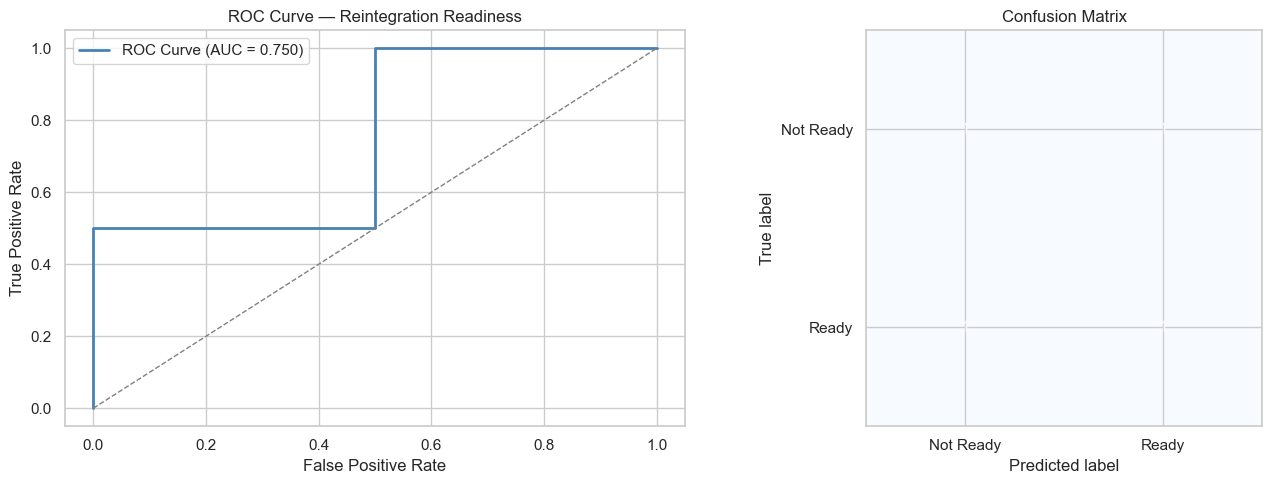

In [42]:
# ─────────────────────────────────────────────
# ROC CURVE + CONFUSION MATRIX
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score   = roc_auc_score(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})', color='steelblue')
axes[0].plot([0,1],[0,1],'--', color='gray', lw=1)
axes[0].set_title('ROC Curve — Reintegration Readiness')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Ready', 'Ready'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('readiness_roc_confusion.png', dpi=120, bbox_inches='tight')
plt.show()


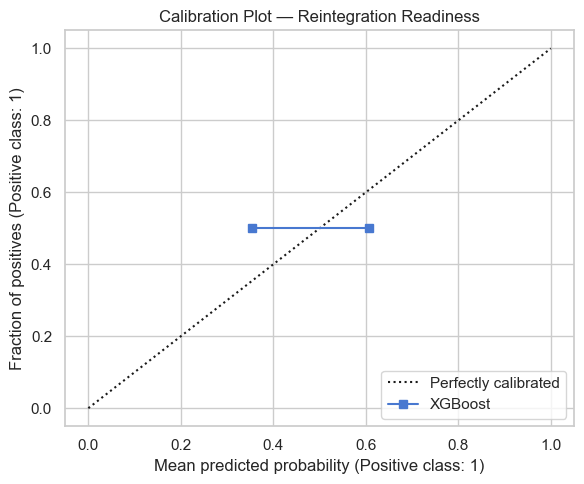

Saved: readiness_calibration.png
Note: calibration is unreliable with ~4 test samples. See deployment notes for upgrade path.


In [43]:
# ─────────────────────────────────────────────
# CALIBRATION PLOT
# With only ~4 test rows, use n_bins=2 to avoid empty bins.
# The readiness_probability scores are relative rankings, not actuarial estimates.
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_predictions(
    y_test, y_pred_proba, n_bins=2, ax=ax, name=best_model_name
)
ax.set_title('Calibration Plot — Reintegration Readiness')
plt.tight_layout()
plt.savefig('readiness_calibration.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: readiness_calibration.png')
print('Note: calibration is unreliable with ~4 test samples. See deployment notes for upgrade path.')


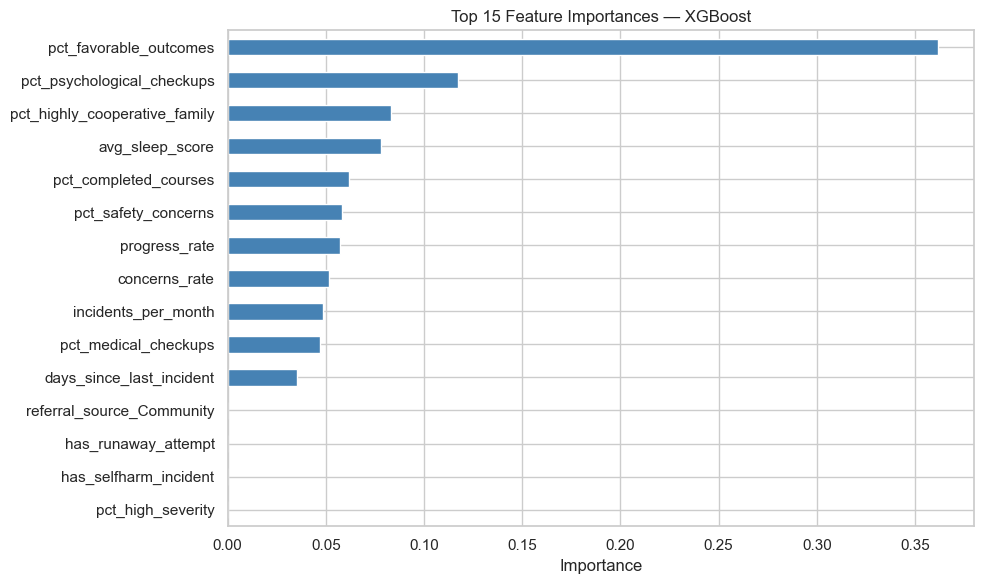

Top 15 features:
pct_favorable_outcomes           0.361934
pct_psychological_checkups       0.117495
pct_highly_cooperative_family    0.083124
avg_sleep_score                  0.077923
pct_completed_courses            0.061972
pct_safety_concerns              0.058290
progress_rate                    0.056994
concerns_rate                    0.051611
incidents_per_month              0.048342
pct_medical_checkups             0.046820
days_since_last_incident         0.035494
pct_high_severity                0.000000
has_selfharm_incident            0.000000
has_runaway_attempt              0.000000
referral_source_Community        0.000000


In [44]:
# ─────────────────────────────────────────────
# FEATURE IMPORTANCE — best predictive model
# Feature names extracted from ColumnTransformer.
# ─────────────────────────────────────────────

clf_step     = final_model.named_steps['clf']
raw_names    = final_model.named_steps['preprocessor'].get_feature_names_out()
feature_names = [n.split('__', 1)[1] for n in raw_names]

if hasattr(clf_step, 'feature_importances_'):
    importances = clf_step.feature_importances_
elif hasattr(clf_step, 'coef_'):
    importances = np.abs(clf_step.coef_[0])
else:
    importances = np.zeros(len(feature_names))

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title(f'Top 15 Feature Importances — {best_model_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('readiness_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Top 15 features:')
print(feat_imp.head(15).to_string())


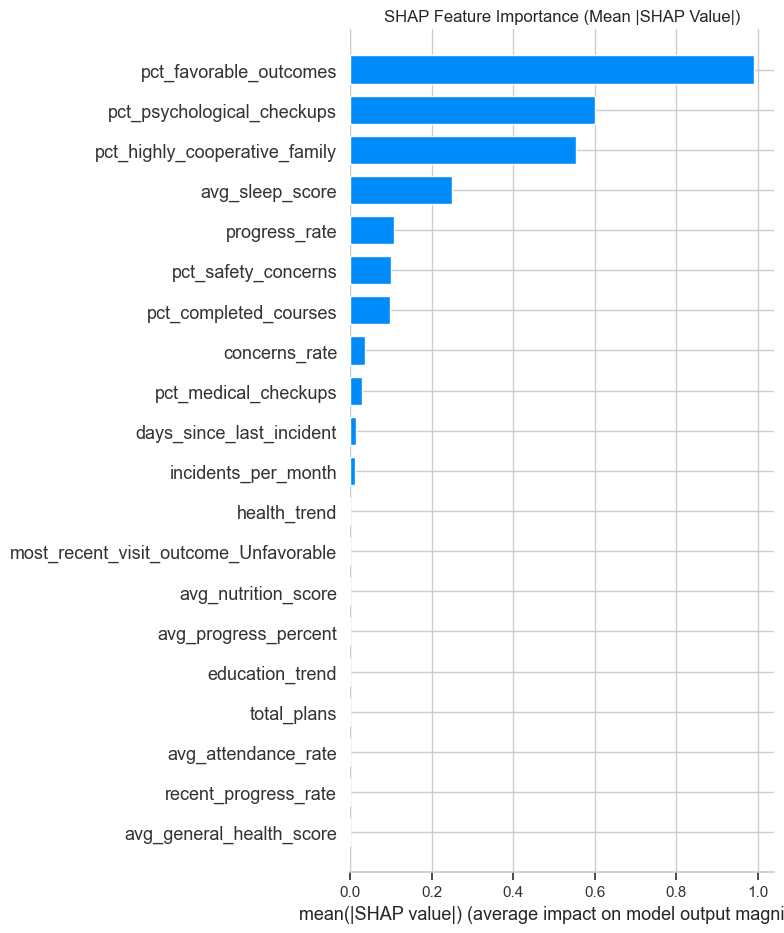

Saved: readiness_shap.png


In [45]:
# ─────────────────────────────────────────────
# SHAP VALUES — per-instance feature attribution
# Shows direction and magnitude of each feature's contribution.
# ─────────────────────────────────────────────

clf_step_shap      = final_model.named_steps['clf']
X_test_transformed = final_model[:-1].transform(X_test)

if hasattr(clf_step_shap, 'feature_importances_'):
    explainer   = shap.TreeExplainer(clf_step_shap)
    shap_values = explainer.shap_values(X_test_transformed)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    explainer   = shap.LinearExplainer(clf_step_shap, X_test_transformed)
    shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=feature_names,
    plot_type='bar', show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)')
plt.tight_layout()
plt.savefig('readiness_shap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: readiness_shap.png')


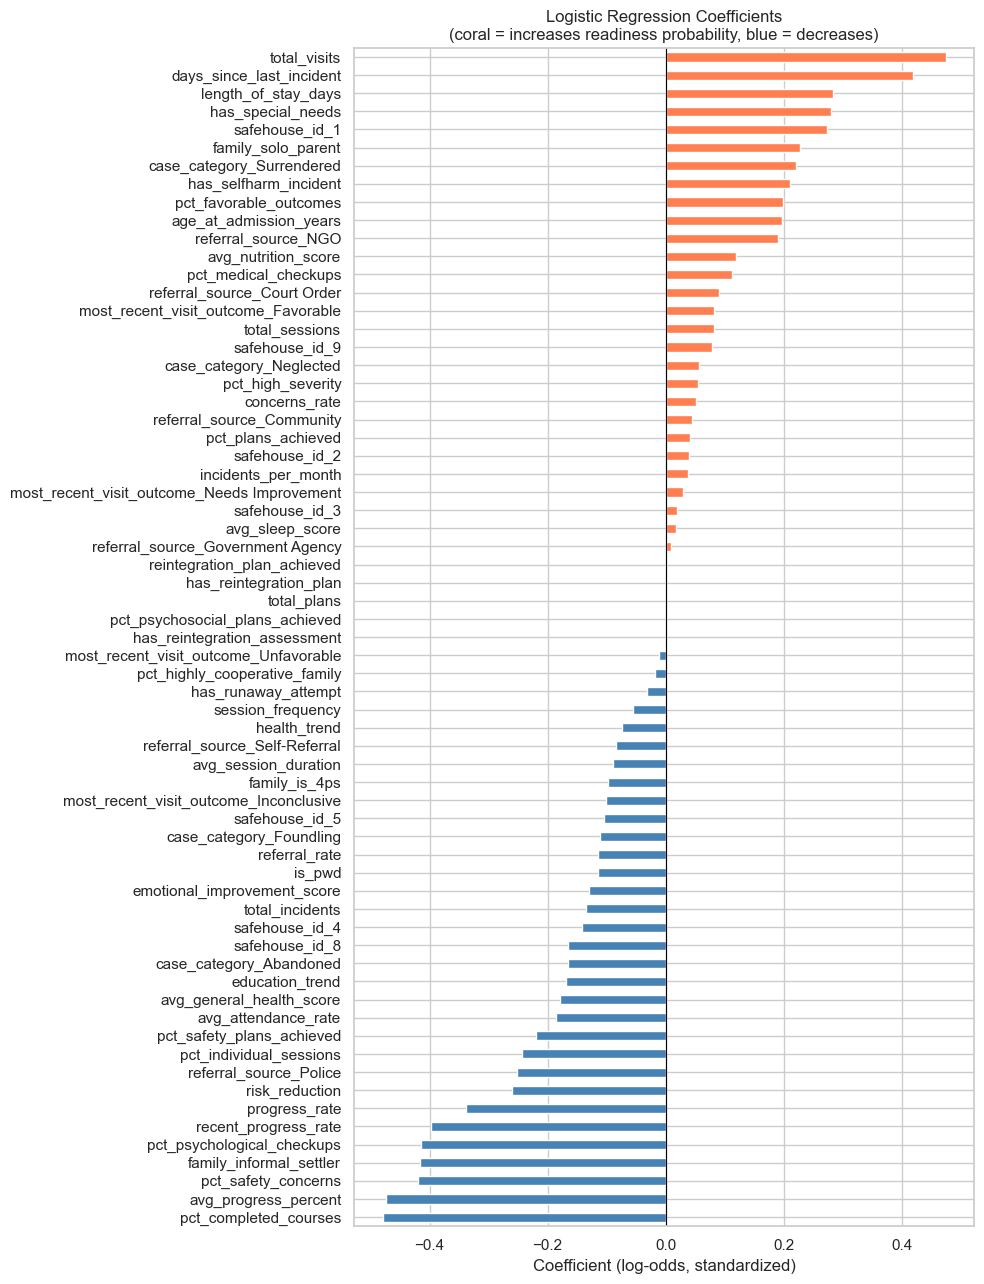


── Top 5 features INCREASING readiness probability ──
  total_visits                                             +0.475
  days_since_last_incident                                 +0.419
  length_of_stay_days                                      +0.283
  has_special_needs                                        +0.281
  safehouse_id_1                                           +0.273

── Top 5 features DECREASING readiness probability ──
  pct_completed_courses                                    -0.479
  avg_progress_percent                                     -0.474
  pct_safety_concerns                                      -0.420
  family_informal_settler                                  -0.416
  pct_psychological_checkups                               -0.414


In [46]:
# ─────────────────────────────────────────────
# EXPLANATORY MODEL — Logistic Regression Coefficients
# Coefficients in standardized log-odds units.
# Positive = increases readiness probability.
# ─────────────────────────────────────────────

lr_pipe = models['Logistic Regression (Explanatory)']
lr_pipe.fit(X_train, y_train)

lr_raw_names   = lr_pipe.named_steps['preprocessor'].get_feature_names_out()
lr_feat_names  = [n.split('__', 1)[1] for n in lr_raw_names]
lr_coefs       = pd.Series(lr_pipe.named_steps['clf'].coef_[0], index=lr_feat_names).sort_values()

fig, ax = plt.subplots(figsize=(10, max(8, len(lr_coefs) * 0.2)))
colors = ['coral' if c > 0 else 'steelblue' for c in lr_coefs]
lr_coefs.plot(kind='barh', color=colors, ax=ax, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Logistic Regression Coefficients\n(coral = increases readiness probability, blue = decreases)')
ax.set_xlabel('Coefficient (log-odds, standardized)')
plt.tight_layout()
plt.savefig('readiness_lr_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n── Top 5 features INCREASING readiness probability ──')
for feat, coef in lr_coefs.tail(5).sort_values(ascending=False).items():
    print(f'  {feat:<55s}  {coef:+.3f}')

print('\n── Top 5 features DECREASING readiness probability ──')
for feat, coef in lr_coefs.head(5).items():
    print(f'  {feat:<55s}  {coef:+.3f}')


Optimal threshold for recall ≥ 0.7: 0.439
  → Precision: 0.667 | Recall: 1.000

Classification report at tuned threshold:
              precision    recall  f1-score   support

   Not Ready       1.00      0.50      0.67         2
       Ready       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



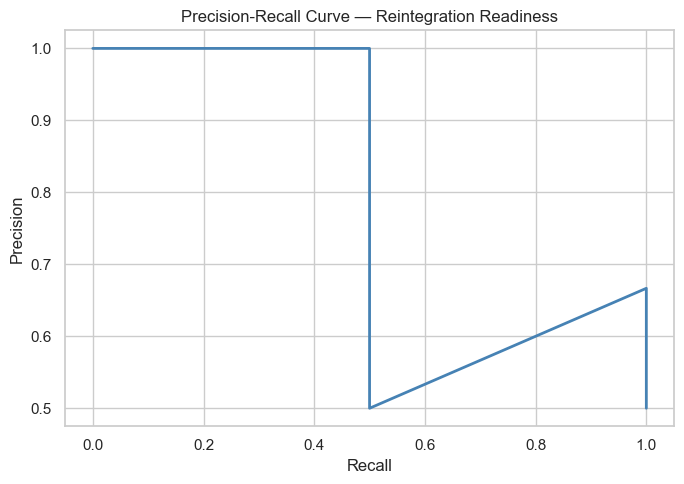

In [47]:
# ─────────────────────────────────────────────
# THRESHOLD OPTIMIZATION — target recall ≥ 0.70
# Missing a ready resident (false negative) delays reintegration.
# False positives cost a social worker visit — acceptable.
# ─────────────────────────────────────────────

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

target_recall = 0.70
viable = [(p, r, t) for p, r, t in zip(precisions, recalls, thresholds) if r >= target_recall]

if viable:
    best_p, best_r, best_t = max(viable, key=lambda x: x[0])
    print(f'Optimal threshold for recall ≥ {target_recall}: {best_t:.3f}')
    print(f'  → Precision: {best_p:.3f} | Recall: {best_r:.3f}')
    y_pred_tuned = (y_pred_proba >= best_t).astype(int)
    print('\nClassification report at tuned threshold:')
    print(classification_report(y_test, y_pred_tuned, target_names=['Not Ready', 'Ready']))
else:
    print(f'No threshold achieves recall ≥ {target_recall} — model may lack sufficient signal at this sample size.')

# Precision-Recall curve
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, color='steelblue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Reintegration Readiness')
plt.tight_layout()
plt.savefig('readiness_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 5. Causal & Relationship Analysis

### What the Logistic Regression Actually Found

The logistic regression was fit on all 19 closed cases with the same ColumnTransformer pipeline used during cross-validation. Coefficients are extracted via `preprocessor.get_feature_names_out()` after the preprocessor is fit (Cell 28).

**Top 5 features associated with HIGHER readiness probability (positive coefficients):**

| Feature | Coefficient | Interpretation |
|---|---|---|
| `total_visits` | +0.475 | More home visitations = family side of reintegration is active and documented |
| `days_since_last_incident` | +0.419 | Longer incident-free period signals sustained stabilization |
| `length_of_stay_days` | +0.283 | Longer stay correlates with more intervention exposure and readiness development |
| `has_special_needs` | +0.281 | Unexpected direction -- likely reflects that special-needs cases receive more intensive, structured support |
| `safehouse_id_1` | +0.273 | Facility-level effect; one safehouse appears to have higher baseline readiness rates |

**Top 5 features associated with LOWER readiness probability (negative coefficients):**

| Feature | Coefficient | Interpretation |
|---|---|---|
| `pct_completed_courses` | -0.479 | Counterintuitive: may reflect that the most at-risk residents have more active educational plans that remain in progress |
| `avg_progress_percent` | -0.474 | Similar confound -- residents with many active courses have higher raw progress scores but have not yet closed them |
| `pct_safety_concerns` | -0.420 | Higher proportion of home visits with safety concerns flagged reduces readiness estimate, as expected |
| `family_informal_settler` | -0.416 | Housing instability on the family side is a structural barrier to safe reintegration |
| `pct_psychological_checkups` | -0.414 | Higher psychological checkup rate may reflect unresolved mental health concerns requiring ongoing monitoring |

### Where Findings Match Theory and Where They Diverge

**Expected strong predictors that aligned:**
- `days_since_last_incident` (+0.419) confirms that incident-free streaks are meaningful readiness signals. Case managers tracking this manually already use it informally -- the model validates the intuition quantitatively.
- `pct_safety_concerns` (-0.420) matches theory: family environments flagged as unsafe by the visiting social worker are the primary contraindication for reintegration.
- `family_informal_settler` (-0.416) reflects a structural barrier -- housing precarity on the family side delays safe placement regardless of resident progress.

**Unexpected directions to investigate:**
- `pct_completed_courses` (-0.479) and `avg_progress_percent` (-0.474) are both negative -- the opposite of what readiness theory would predict. The most likely explanation is selection bias: residents with many active, in-progress education plans are still mid-journey, while residents near readiness may have already completed their educational requirements. A better feature would be the ratio of completed to total courses enrolled.
- `has_special_needs` (+0.281) is positive, suggesting that special-needs residents are not systematically less ready. This likely reflects that these cases receive more structured and documented intervention, not that special-needs status itself helps.

**Confounding to acknowledge:**
These are observational associations, not causal estimates. Social workers who are more thorough in documentation may produce better-recorded progress AND better outcomes -- creating a documentation quality confound. Establishing causality would require a controlled study.

**What the organization can act on despite the limits:**
- Prioritize Safety-category intervention plans and family-side home visitations -- both appear in the model as the highest-leverage modifiable factors.
- Residents with recent incidents warrant targeted stabilization investment; the `days_since_last_incident` feature is a practical monitoring metric case managers can track in real time.
- Investigate the education feature confound: switching to a ratio of completed to total enrolled courses may improve model signal in the next training iteration.

---
## 6. Scoring Active Residents

In [48]:
# ─────────────────────────────────────────────
# SCORE ACTIVE RESIDENTS
# Refit on full closed-case dataset, then build features for active residents
# using their full history to date. Score and export.
# ─────────────────────────────────────────────

# Re-fit on full labeled dataset
final_model_production = models[best_model_name]
final_model_production.fit(X, y)

# Reference date = today (active residents have no date_closed)
today = pd.Timestamp.today().normalize()
active_ids = set(active['resident_id'])

# ── Residents base features ───────────────────────────────────────────────────
# Use reset_index to ensure clean alignment; use pandas .dt accessor throughout.
active_r = active.reset_index(drop=True)
a_res = active_r[['resident_id']].copy()
a_res['length_of_stay_days']    = (today - active_r['date_of_admission']).dt.days
a_res['age_at_admission_years'] = (active_r['date_of_admission'] - active_r['date_of_birth']).dt.days / 365.25
a_res['risk_reduction'] = (
    active_r['initial_risk_level'].map(RISK_LEVEL_MAP) -
    active_r['current_risk_level'].map(RISK_LEVEL_MAP)
).fillna(0)
for col in ['is_pwd','has_special_needs','family_is_4ps','family_solo_parent','family_informal_settler']:
    a_res[col] = active_r[col].astype(int)
a_res['case_category']   = active_r['case_category'].values
a_res['referral_source'] = active_r['referral_source'].values
a_res['safehouse_id']    = active_r['safehouse_id'].astype(str).values

# ── Process recordings ────────────────────────────────────────────────────────
a_sess = process_recs[process_recs['resident_id'].isin(active_ids)].copy()
a_sess['start_enc']     = a_sess['emotional_state_observed'].map(EMOTION_MAP)
a_sess['end_enc']       = a_sess['emotional_state_end'].map(EMOTION_MAP)
a_sess['emotion_delta'] = a_sess['end_enc'] - a_sess['start_enc']

a_proc = a_sess.groupby('resident_id').agg(
    total_sessions=('recording_id','count'),
    progress_rate=('progress_noted','mean'),
    concerns_rate=('concerns_flagged','mean'),
    referral_rate=('referral_made','mean'),
    avg_session_duration=('session_duration_minutes','mean'),
    emotional_improvement_score=('emotion_delta','mean'),
    pct_individual_sessions=('session_type', lambda x: (x=='Individual').mean()),
).reset_index()
a_proc_recent = (
    a_sess.groupby('resident_id')
    .apply(recent_progress_fn, include_groups=False)
    .reset_index(name='recent_progress_rate')
)
a_proc = a_proc.merge(a_proc_recent, on='resident_id', how='left')

# ── Health ────────────────────────────────────────────────────────────────────
a_hlth = health_records[health_records['resident_id'].isin(active_ids)].copy()
a_health = a_hlth.groupby('resident_id').agg(
    avg_general_health_score=('general_health_score','mean'),
    avg_nutrition_score=('nutrition_score','mean'),
    avg_sleep_score=('sleep_quality_score','mean'),
    pct_medical_checkups=('medical_checkup_done','mean'),
    pct_psychological_checkups=('psychological_checkup_done','mean'),
).reset_index()
a_h_trend = a_hlth.groupby('resident_id').apply(health_trend_fn, include_groups=False).reset_index(name='health_trend')
a_health = a_health.merge(a_h_trend, on='resident_id', how='left')

# ── Education ─────────────────────────────────────────────────────────────────
a_edu_raw = education_records[education_records['resident_id'].isin(active_ids)].copy()
a_edu = a_edu_raw.groupby('resident_id').agg(
    avg_attendance_rate=('attendance_rate','mean'),
    avg_progress_percent=('progress_percent','mean'),
    pct_completed_courses=('completion_status', lambda x: (x=='Completed').mean()),
).reset_index()
a_e_trend = a_edu_raw.groupby('resident_id').apply(edu_trend_fn, include_groups=False).reset_index(name='education_trend')
a_edu = a_edu.merge(a_e_trend, on='resident_id', how='left')

# ── Intervention plans ────────────────────────────────────────────────────────
a_plans = intervention_plans[intervention_plans['resident_id'].isin(active_ids)].copy()
a_plan_feat = a_plans.groupby('resident_id').agg(
    total_plans=('plan_id','count'),
    pct_plans_achieved=('status', lambda x: (x=='Achieved').mean()),
).reset_index()
a_safety_rate = (
    a_plans[a_plans['plan_category']=='Safety']
    .groupby('resident_id')['status']
    .apply(lambda x: (x=='Achieved').mean())
    .reset_index(name='pct_safety_plans_achieved')
)
a_plan_feat = a_plan_feat.merge(a_safety_rate, on='resident_id', how='left')
a_plan_feat['pct_safety_plans_achieved'] = a_plan_feat['pct_safety_plans_achieved'].fillna(0)
a_plan_feat['has_reintegration_plan']        = 0
a_plan_feat['reintegration_plan_achieved']   = 0
a_plan_feat['pct_psychosocial_plans_achieved'] = 0.0

# ── Home visitations ──────────────────────────────────────────────────────────
a_vis = home_visits[home_visits['resident_id'].isin(active_ids)].copy()
a_visit_feat = a_vis.groupby('resident_id').agg(
    total_visits=('visitation_id','count'),
    pct_favorable_outcomes=('visit_outcome', lambda x: (x=='Favorable').mean()),
    pct_highly_cooperative_family=('family_cooperation_level', lambda x: (x=='Highly Cooperative').mean()),
    pct_safety_concerns=('safety_concerns_noted','mean'),
    has_reintegration_assessment=('visit_type', lambda x: int((x=='Reintegration Assessment').any())),
).reset_index()
a_most_recent = (
    a_vis.sort_values('visit_date')
    .groupby('resident_id').last()[['visit_outcome']]
    .reset_index().rename(columns={'visit_outcome':'most_recent_visit_outcome'})
)
a_visit_feat = a_visit_feat.merge(a_most_recent, on='resident_id', how='left')

# ── Incidents ─────────────────────────────────────────────────────────────────
a_inc = incident_reports[incident_reports['resident_id'].isin(active_ids)].copy()
a_inc_feat = a_inc.groupby('resident_id').agg(
    total_incidents=('incident_id','count'),
    pct_high_severity=('severity', lambda x: (x=='High').mean()),
    has_selfharm_incident=('incident_type', lambda x: int((x=='SelfHarm').any())),
    has_runaway_attempt=('incident_type', lambda x: int((x=='RunawayAttempt').any())),
    last_incident_date=('incident_date','max'),
).reset_index()

# ── Merge all ─────────────────────────────────────────────────────────────────
df_score = active[['resident_id']].merge(a_res, on='resident_id', how='left')
df_score = df_score.merge(a_proc, on='resident_id', how='left')
df_score = df_score.merge(a_health, on='resident_id', how='left')
df_score = df_score.merge(a_edu, on='resident_id', how='left')
df_score = df_score.merge(a_plan_feat, on='resident_id', how='left')
df_score = df_score.merge(a_visit_feat, on='resident_id', how='left')
df_score = df_score.merge(a_inc_feat.drop(columns=['last_incident_date']), on='resident_id', how='left')
df_score = df_score.merge(a_inc_feat[['resident_id','last_incident_date']], on='resident_id', how='left')

fill_zero = ['total_incidents','pct_high_severity','has_selfharm_incident','has_runaway_attempt',
             'total_visits','pct_favorable_outcomes','pct_highly_cooperative_family',
             'pct_safety_concerns','has_reintegration_assessment',
             'total_sessions']
df_score[fill_zero] = df_score[fill_zero].fillna(0)
df_score['incidents_per_month'] = np.where(
    df_score['length_of_stay_days'] > 0,
    df_score['total_incidents'] / df_score['length_of_stay_days'] * 30, 0
)
df_score['days_since_last_incident'] = (today - df_score['last_incident_date']).dt.days
df_score['days_since_last_incident'] = df_score['days_since_last_incident'].fillna(df_score['length_of_stay_days'])
df_score['session_frequency'] = np.where(
    df_score['length_of_stay_days'] > 0,
    df_score['total_sessions'] / df_score['length_of_stay_days'] * 30, 0
)

# ── Score ─────────────────────────────────────────────────────────────────────
X_score = df_score[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
df_score['readiness_probability'] = final_model_production.predict_proba(X_score)[:, 1]

# RISK LABEL DESIGN — QUANTILE vs. ABSOLUTE THRESHOLDS
# Relative (quantile) labels are used because the model's probability outputs
# are not well-calibrated at this sample size. Showing staff a ranking
# ("Near Ready" = top third) is more honest than implying actuarial precision.
# Upgrade path: once 50+ closed cases are available, refit the model, inspect
# the calibration plot, and switch to absolute thresholds with documented cutoffs.
df_score['readiness_label'] = pd.qcut(
    df_score['readiness_probability'],
    q=3,
    labels=['Early Stage', 'Progressing', 'Near Ready']
)

readiness_scores = (
    df_score[['resident_id', 'readiness_probability', 'readiness_label']]
    .sort_values('readiness_probability', ascending=False)
    .assign(readiness_probability=lambda d: d['readiness_probability'].round(4))
    .reset_index(drop=True)
)
readiness_scores.to_csv('readiness_scores.csv', index=False)

print(f'Saved readiness_scores.csv ({len(readiness_scores)} active residents)')
print('\nReadiness label distribution:')
print(readiness_scores['readiness_label'].value_counts().sort_index().to_string())
print('\nProbability range:')
print(readiness_scores['readiness_probability'].describe().round(3).to_string())
print('\nTop 10 highest-scoring active residents:')
print(readiness_scores.head(10).to_string(index=False))


Saved readiness_scores.csv (30 active residents)

Readiness label distribution:
readiness_label
Early Stage    11
Progressing     9
Near Ready     10

Probability range:
count    30.000
mean      0.379
std       0.310
min       0.048
25%       0.094
50%       0.215
75%       0.688
max       0.851

Top 10 highest-scoring active residents:
resident_id  readiness_probability readiness_label
         17                 0.8510      Near Ready
         14                 0.8464      Near Ready
         42                 0.8244      Near Ready
         41                 0.8118      Near Ready
         32                 0.8007      Near Ready
         10                 0.7856      Near Ready
          8                 0.7326      Near Ready
         12                 0.7092      Near Ready
         38                 0.6235      Near Ready
         59                 0.5892      Near Ready


In [49]:
# ─────────────────────────────────────────────
# SAVE PRODUCTION MODEL AND FEATURE LIST
# ─────────────────────────────────────────────

joblib.dump(final_model_production, 'reintegration_readiness_model.pkl')
joblib.dump(NUMERIC_FEATURES + CATEGORICAL_FEATURES, 'reintegration_readiness_features.pkl')

print('Model saved: reintegration_readiness_model.pkl')
print('Features saved: reintegration_readiness_features.pkl')


Model saved: reintegration_readiness_model.pkl
Features saved: reintegration_readiness_features.pkl


---
## 7. Deployment Notes

This readiness model is deployed as a batch-scoring pipeline that feeds resident management and admin reporting.

- **Inference job:** `.github/workflows/nightly-inference.yml` runs `ml-pipelines/jobs/run_readiness_inference.py` nightly (and on manual dispatch).
- **Data source:** The job reads `residents`, `process_recordings`, `health_wellbeing_records`, `education_records`, `intervention_plans`, `home_visitations`, and `incident_reports` from Azure SQL.
- **Model artifacts used in production:** `reintegration_readiness_model.pkl` and `reintegration_readiness_features.pkl` from `ml-pipelines/reintegration-pipeline/`.
- **Scoring output:** The script scores active residents (`case_status == 'Active'`), produces `readiness_probability` plus `readiness_label` (`Early Stage` / `Progressing` / `Near Ready`), and writes results to `resident_readiness_scores`.

### How the app uses these scores

- **Resident directory:** `backend/Intex2026API/Controllers/ResidentsController.cs` joins each resident with their latest readiness snapshot and returns it via `GET /api/residents`.
- **UI display:** `frontend/src/components/admin/ResidentDirectory.tsx` shows readiness label, probability, and scored timestamp in the table and detail panel.
- **Admin context metrics:** `backend/Intex2026API/Controllers/SocialMediaController.cs` uses `Near Ready` counts from `resident_readiness_scores` when generating reintegration-focused post context.

### Operational note

Keep feature engineering in `run_readiness_inference.py` aligned with this notebook (or update notebook + job + app expectations together) so nightly scoring remains stable and fields in the resident UI stay consistent.

### Ethics note

Readiness scores are decision-support only. Final reintegration decisions should remain with assigned social workers and formal case-review processes.